# Where Should a New Restaurant Open in Bangalore?
## A Data-Driven Market Analysis Using Zomato Data

### Project Overview
This project explores the Bangalore restaurant market using data from Zomato.  
The goal is to analyze restaurant locations, cuisine trends, pricing patterns, and customer engagement in order to identify potential opportunities for opening a new restaurant.

### Key Questions
- Which locations have the highest restaurant competition?
- Where is customer demand strongest?
- Which cuisines dominate the Bangalore food market?
- What pricing range is most common?
- Where could new restaurants potentially find opportunities?

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Dataset

The dataset used in this project contains information about restaurants listed on Zomato in Bangalore.

Key columns include:

- Restaurant Name
- Location
- Cuisine Types
- Rating
- Number of Votes
- Approximate Cost for Two People

This dataset helps analyze restaurant competition, demand patterns, and pricing strategies in the Bangalore food ecosystem.

## load the data set

In [2]:
df = pd.read_csv("zomato_bangalore.csv")

df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Cleaning 

In [3]:
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [4]:
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [5]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

In [6]:
rest = df[['name','location','cuisines','rate','votes','approx_cost(for two people)']]

In [7]:
rest.head()

,name,location,cuisines,rate,votes,approx_cost(for two people)
0,Jalsa,Banashankari,"North Indian, Mughlai, Chinese",4.1,775,800.0
1,Spice Elephant,Banashankari,"Chinese, North Indian, Thai",4.1,787,800.0
2,San Churro Cafe,Banashankari,"Cafe, Mexican, Italian",3.8,918,800.0
3,Addhuri Udupi Bhojana,Banashankari,"South Indian, North Indian",3.7,88,300.0
4,Grand Village,Basavanagudi,"North Indian, Rajasthani",3.8,166,600.0


## Restaurant Competition Across Bangalore

In this section we analyze how restaurants are distributed across different locations in Bangalore.  
High restaurant density may indicate strong food culture but also higher competition.

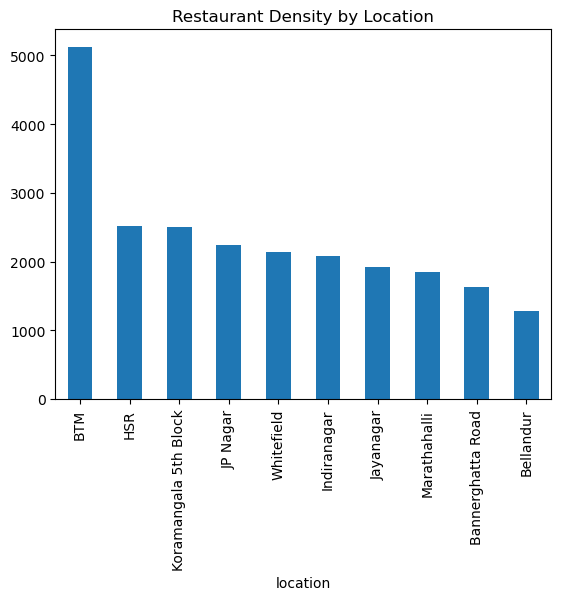

In [8]:
# Market Competition Map Restaurant density by location

df['location'].value_counts().head(10).plot(kind='bar')

plt.title("Restaurant Density by Location")

plt.show()

## INSIGHT:
- High density = high competition
- Low density = market opportunity

## Customer Demand Analysis

Customer votes on Zomato are used as a proxy for demand.  
Higher votes indicate stronger engagement from customers.

In [9]:
#Demand Indicator Use votes as demand.
df.groupby('location')['votes'].mean().sort_values(ascending=False).head(10)

location
Church Street            1045.657293
Lavelle Road              956.873346
Koramangala 5th Block     886.384185
St. Marks Road            755.963068
Koramangala 4th Block     673.703048
Cunningham Road           586.299389
Koramangala 3rd Block     579.439815
Indiranagar               574.175228
MG Road                   470.709150
Residency Road            432.524444
Name: votes, dtype: float64

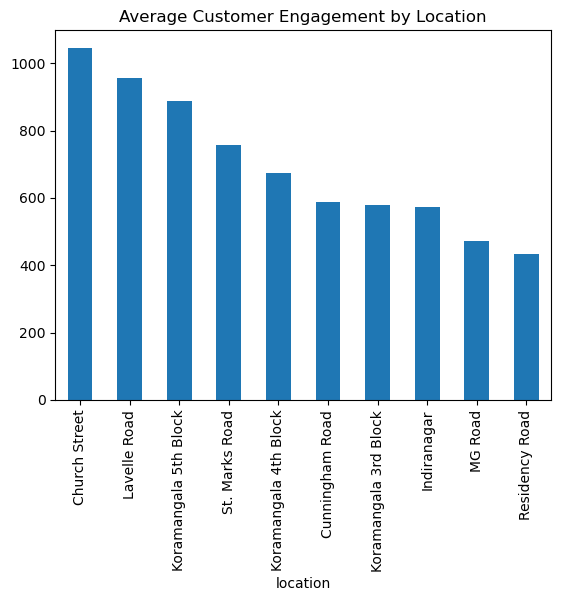

In [10]:
df.groupby('location')['votes'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Average Customer Engagement by Location")
plt.show()

# INSIGHT:
- Locations with high votes = strong demand.

## Cuisine Market Trends

Understanding which cuisines dominate the market can help restaurant owners choose menus aligned with customer preferences.

In [11]:
#Cuisine Market Share
cuisines = df['cuisines'].str.split(',').explode()  
cuisines = df['cuisines'].dropna().str.split(',')    ## Split cuisines
cuisines = cuisines.explode()                       # Convert list into rows          
cuisines = cuisines.str.strip()                    # Remove extra spaces
top_cuisines = cuisines.value_counts().head(10)        # Count cuisines
cuisines

0        North Indian
0             Mughlai
0             Chinese
1             Chinese
1        North Indian
             ...     
51714     Finger Food
51715     Finger Food
51716     Finger Food
51716    North Indian
51716     Continental
Name: cuisines, Length: 126819, dtype: object

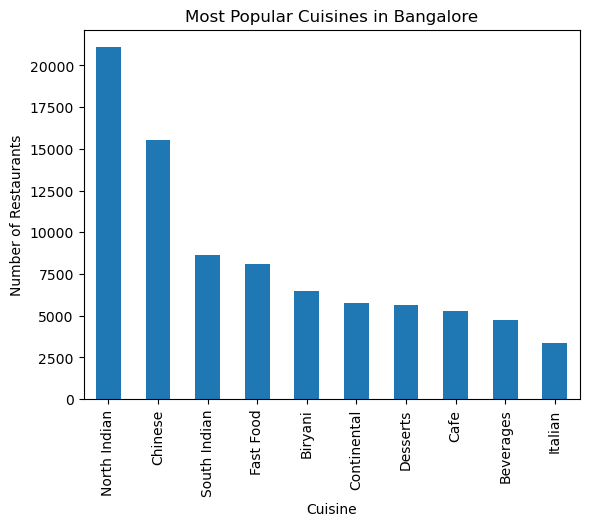

In [12]:
top_cuisines.plot(kind='bar')
plt.title("Most Popular Cuisines in Bangalore")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

plt.show()

# INSIGHT:
- Which cuisines dominate the market.

## Pricing Strategy Analysis

This section explores the distribution of restaurant pricing to understand the most common cost range for dining in Bangalore.

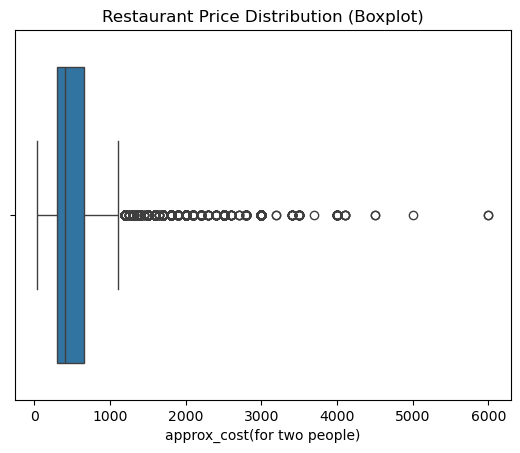

In [13]:
# Pricing Strategy

sns.boxplot(x=df['approx_cost(for two people)'])

plt.title("Restaurant Price Distribution (Boxplot)")

plt.show()

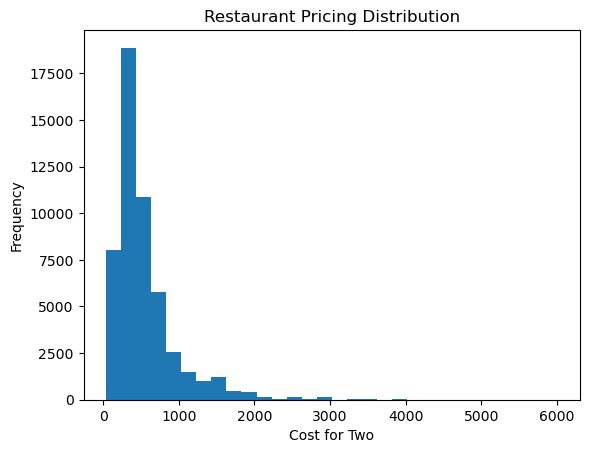

In [14]:
# Cost distribution
df['approx_cost(for two people)'].plot(kind='hist', bins=30)

plt.title("Restaurant Pricing Distribution")
plt.xlabel("Cost for Two")
plt.ylabel("Frequency")

plt.show()

# INSIGHT:
- Most restaurants fall in ₹300–₹700 price range.This indicates mid-range pricing strategy works best.

## Relationship Between Ratings and Popularity

Customer ratings often influence restaurant visibility and engagement.  
This analysis explores how ratings relate to customer votes.

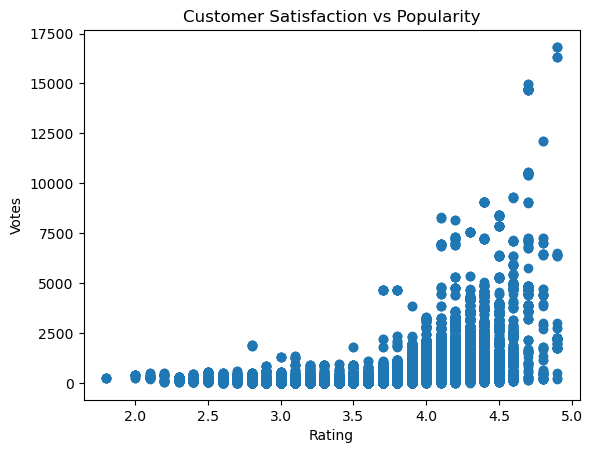

In [15]:
#Quality vs Popularity

plt.scatter(df['rate'], df['votes'])

plt.xlabel("Rating")

plt.ylabel("Votes")

plt.title("Customer Satisfaction vs Popularity")

plt.show()

# INSIGHT:
- Higher ratings → higher customer engagement.

## Market Opportunity Analysis

To identify potential opportunities for new restaurants, a simple metric called the **Opportunity Score** is introduced.

Opportunity Score = Demand / Competition

Where:
- Demand is represented by average customer votes
- Competition is represented by restaurant density

In [16]:
#Create a Market Opportunity Score ,Opportunity Index
#Opportunity Score = Demand / Competition

location_demand = df.groupby('location')['votes'].mean()
location_competition = df['location'].value_counts()
market = pd.DataFrame({'demand': location_demand,'competition': location_competition})
market['opportunity_score'] = market['demand'] / market['competition']
market.sort_values(by='opportunity_score', ascending=False).head(10)

,demand,competition,opportunity_score
location,,,
Rajarajeshwari Nagar,366.000000,2,183.000000
West Bangalore,185.000000,6,30.833333
Central Bangalore,153.125000,8,19.140625
Sankey Road,237.444444,27,8.794239
North Bangalore,118.785714,14,8.484694
Langford Town,195.592593,27,7.244170
Kengeri,50.666667,9,5.629630
Yelahanka,31.500000,6,5.250000
Peenya,5.000000,1,5.000000


## best locations for new restaurants.

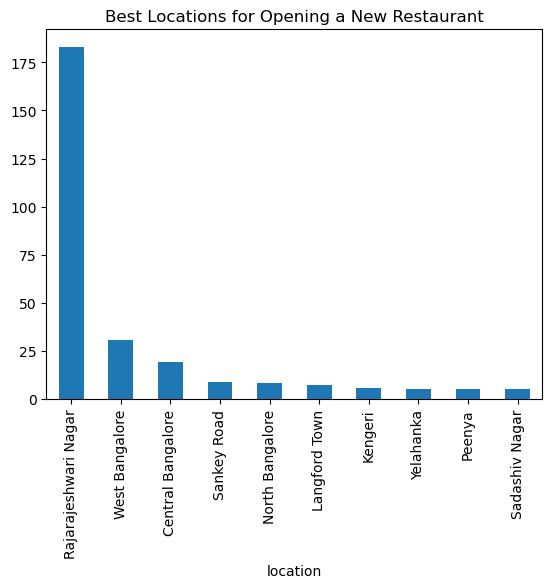

In [17]:
# Visualize Opportunity Locations
market.sort_values(by='opportunity_score', ascending=False).head(10)['opportunity_score'].plot(kind='bar')
plt.title("Best Locations for Opening a New Restaurant")
plt.show()


## Conclusion

This analysis provides insights into the Bangalore restaurant market using data from Zomato.

Key takeaways include:

- Areas like BTM and Koramangala have high restaurant density, indicating strong competition.
- Locations such as Church Street show strong customer demand.
- North Indian and Chinese cuisines dominate the market.
- Most restaurants fall within the ₹200–₹800 price range.
- Some emerging areas show potential opportunities for new restaurants.

While data cannot guarantee business success, data-driven insights can help entrepreneurs make more informed decisions when entering competitive markets.